In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import cv2
from glob import glob
from sklearn.model_selection import train_test_split

# Define base directory
base_dir = '/content/drive/MyDrive/'

# Construct full paths for image and mask folders
image_dir = "/content/drive/MyDrive/Images"
mask_dir = "/content/drive/MyDrive/mask"

# List all image and mask file paths, and sort them to maintain correspondence
image_paths = sorted(glob(os.path.join(image_dir, '*.jpg')))
mask_paths = sorted(glob(os.path.join(mask_dir, '*.jpg')))

print(f"Found {len(image_paths)} images and {len(mask_paths)} masks.")
print("First 5 image paths:", image_paths[:5])
print("First 5 mask paths:", mask_paths[:5])

Found 500 images and 500 masks.
First 5 image paths: ['/content/drive/MyDrive/Images/1.jpg', '/content/drive/MyDrive/Images/10.jpg', '/content/drive/MyDrive/Images/100.jpg', '/content/drive/MyDrive/Images/101.jpg', '/content/drive/MyDrive/Images/102.jpg']
First 5 mask paths: ['/content/drive/MyDrive/mask/1.jpg', '/content/drive/MyDrive/mask/10.jpg', '/content/drive/MyDrive/mask/100.jpg', '/content/drive/MyDrive/mask/101.jpg', '/content/drive/MyDrive/mask/102.jpg']


In [ ]:
IMG_SIZE = 224

x_data = []
y_data = []

for img_path, mask_path in zip(image_paths, mask_paths):
    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) # Resize image
    img = img / 255.0  # Normalize to [0, 1]
    x_data.append(img)

    # Load mask
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) # Load as grayscale
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) # Resize mask
    mask = mask / 255.0  # Normalize to [0, 1]
    mask = np.expand_dims(mask, axis=-1) # Add channel dimension for consistency
    y_data.append(mask)

x_data = np.array(x_data, dtype=np.float32)
y_data = np.array(y_data, dtype=np.float32)

# Split data into training and validation sets (80% train, 20% validation)
x_train, x_val, y_train, y_val = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

print(f"Shape of preprocessed images: {x_data.shape}")
print(f"Shape of preprocessed masks: {y_data.shape}")
print(f"Number of training images: {len(x_train)}")
print(f"Number of validation images: {len(x_val)}")

Shape of preprocessed images: (500, 224, 224, 3)
Shape of preprocessed masks: (500, 224, 224, 1)
Number of training images: 400
Number of validation images: 100


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, BatchNormalization, Activation
from tensorflow.keras.models import Model

def build_unet(input_shape):
    inputs = Input(input_shape)

    # Encoder path
    # Block 1
    c1 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    # Block 2
    c2 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    # Block 3
    c3 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    c3 = BatchNormalization()(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    # Block 4
    c4 = Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = BatchNormalization()(c4)
    c4 = Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    c4 = BatchNormalization()(c4)
    p4 = MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(1024, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = BatchNormalization()(c5)
    c5 = Conv2D(1024, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    c5 = BatchNormalization()(c5)

    # Decoder path
    # Block 6
    u6 = UpSampling2D((2, 2))(c5)
    u6 = Concatenate()([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = BatchNormalization()(c6)
    c6 = Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
    c6 = BatchNormalization()(c6)

    # Block 7
    u7 = UpSampling2D((2, 2))(c6)
    u7 = Concatenate()([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = BatchNormalization()(c7)
    c7 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
    c7 = BatchNormalization()(c7)

    # Block 8
    u8 = UpSampling2D((2, 2))(c7)
    u8 = Concatenate()([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = BatchNormalization()(c8)
    c8 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
    c8 = BatchNormalization()(c8)

    # Block 9
    u9 = UpSampling2D((2, 2))(c8)
    u9 = Concatenate()([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = BatchNormalization()(c9)
    c9 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
    c9 = BatchNormalization()(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9) # 1 filter for binary segmentation

    model = Model(inputs=[inputs], outputs=[outputs])

    return model

# Instantiate the U-Net model
IMG_SIZE = 224
input_shape = (IMG_SIZE, IMG_SIZE, 3) # 3 channels for RGB images
unet_model = build_unet(input_shape)

print("U-Net model built successfully.")
print(unet_model.summary())

U-Net model built successfully.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │  1,180,160 │ max_pooling2d_2[

 Total params: 31,402,497 (119.79 MB)

 Trainable params: 31,390,721 (119.75 MB)

 Non-trainable params: 11,776 (46.00 KB)

None


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow.keras.backend as K

# Define the Dice Loss function
def dice_loss(y_true, y_pred):
    smooth = 1e-7
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    sum_areas = K.sum(y_true_f) + K.sum(y_pred_f)
    return 1 - (2. * intersection + smooth) / (sum_areas + smooth)

print("Dice Loss function defined.")

Dice Loss function defined.


In [ ]:
compile_unet_model = build_unet(input_shape)

# Compile the model
compile_unet_model.compile(optimizer=Adam(learning_rate=1e-4), loss=dice_loss, metrics=['binary_crossentropy', dice_loss])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('unet_mango_segmentation.h5', monitor='val_loss', save_best_only=True)

print("U-Net model compiled and callbacks defined.")

# Train the model
history = compile_unet_model.fit(
    x_train, y_train,
    batch_size=8,
    epochs=5,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping, model_checkpoint]
)

print("Model training complete.")

U-Net model compiled and callbacks defined.
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 62s/step - binary_crossentropy: 0.8249 - dice_loss: 0.4632 - loss: 0.4632  

50/50 ━━━━━━━━━━━━━━━━━━━━ 3346s 67s/step - binary_crossentropy: 0.8250 - dice_loss: 0.4618 - loss: 0.4618 - val_binary_crossentropy: 0.4013 - val_dice_loss: 0.8218 - val_loss: 0.8197
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 63s/step - binary_crossentropy: 0.7871 - dice_loss: 0.2942 - loss: 0.2942  

50/50 ━━━━━━━━━━━━━━━━━━━━ 3333s 67s/step - binary_crossentropy: 0.7858 - dice_loss: 0.2938 - loss: 0.2938 - val_binary_crossentropy: 0.2439 - val_dice_loss: 0.3328 - val_loss: 0.3304
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3357s 66s/step - binary_crossentropy: 0.6485 - dice_loss: 0.2436 - loss: 0.2436 - val_binary_crossentropy: 0.4103 - val_dice_loss: 0.3869 - val_loss: 0.3864
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3184s 64s/step - binary_crossentropy: 0.5221 - dice_loss: 0.2030 - loss: 0.2030 - val_binary_crossentropy: 0.4347 - val_dice_loss: 0.4271 - val_loss: 0.4244
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 54s/step - binary_crossentropy: 0.5215 - dice_loss: 0.1981 - loss: 0.1981 

50/50 ━━━━━━━━━━━━━━━━━━━━ 2927s 58s/step - binary_crossentropy: 0.5210 - dice_loss: 0.1979 - loss: 0.1979 - val_binary_crossentropy: 0.3374 - val_dice_loss: 0.2201 - val_loss: 0.2186
Model training complete.


In [ ]:
from tensorflow.keras.models import load_model

# Load the best model saved during training
# Custom objects are needed because dice_loss is a custom loss function
best_model = load_model('unet_mango_segmentation.h5', custom_objects={'dice_loss': dice_loss})

# Make predictions on the validation set
y_pred = best_model.predict(x_val)

# Binarize predictions (threshold at 0.5)
y_pred_binary = (y_pred > 0.5).astype(np.float32)

# Calculate Dice Coefficient on the validation set
# K.mean is used to average across the batch, and K.flatten is used inside dice_loss
dice_coefficient = 1 - best_model.evaluate(x_val, y_val, verbose=0)[2] # Get dice_loss from metrics

print(f"Validation Dice Coefficient: {dice_coefficient:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 185s 41s/step
Validation Dice Coefficient: 0.7805


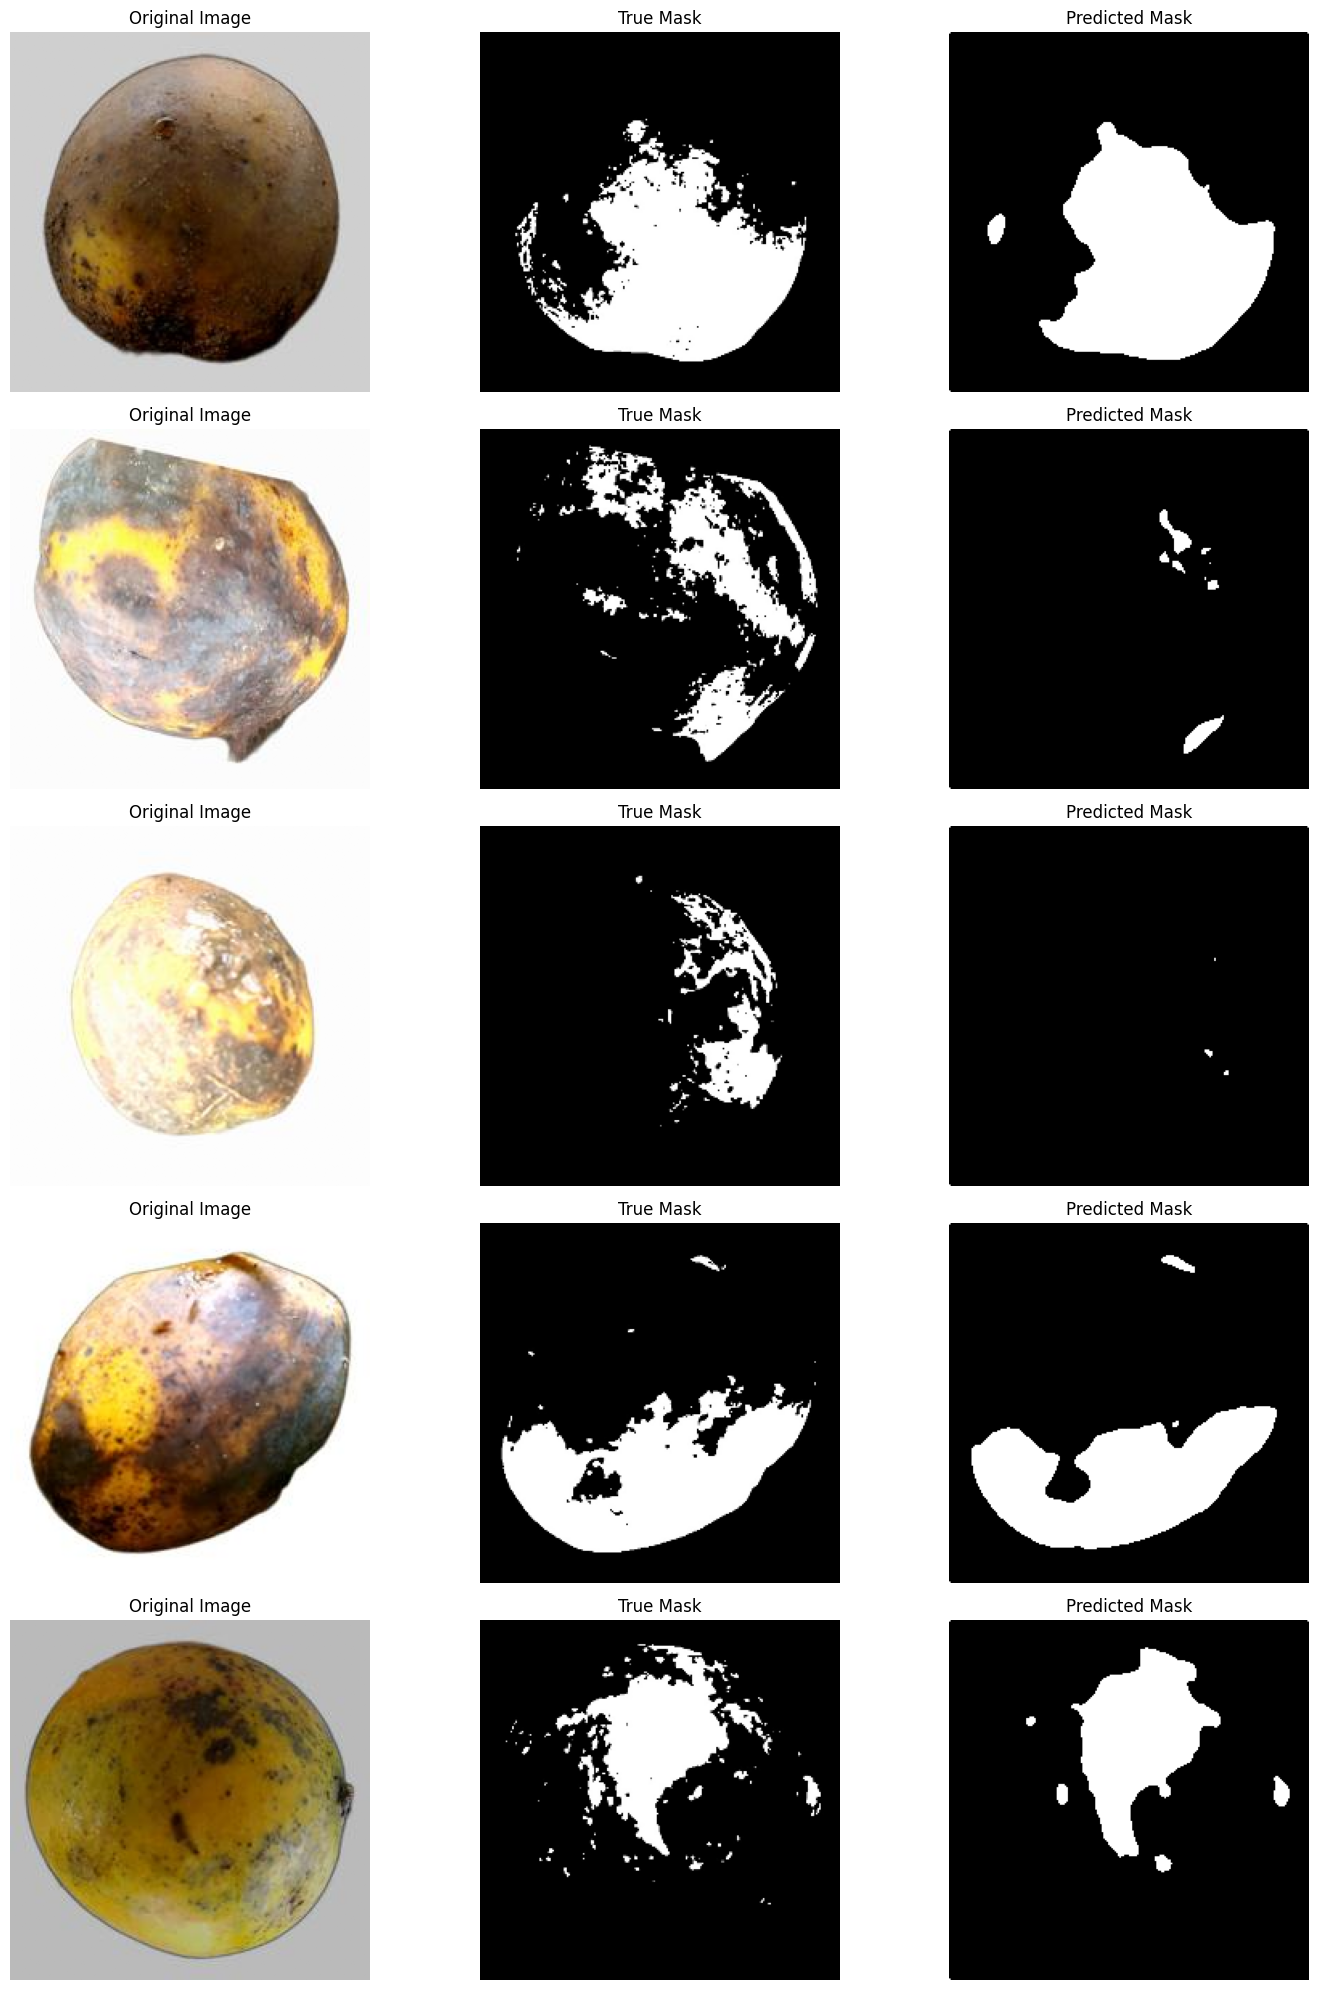

In [ ]:
import matplotlib.pyplot as plt

def visualize_predictions(images, true_masks, pred_masks, num_samples=5):
    plt.figure(figsize=(15, num_samples * 4))

    for i in range(num_samples):
        # Original Image
        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(images[i])
        plt.title("Original Image")
        plt.axis("off")

        # True Mask
        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(true_masks[i].squeeze(), cmap='gray')
        plt.title("True Mask")
        plt.axis("off")

        # Predicted Mask
        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(pred_masks[i].squeeze(), cmap='gray')
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Visualize a few predictions from the validation set
visualize_predictions(x_val, y_val, y_pred_binary, num_samples=5)


In [ ]:
import numpy as np

# Flatten both true masks (y_val) and predicted binary masks (y_pred_binary)
y_val_flat = y_val.flatten()
y_pred_binary_flat = y_pred_binary.flatten()

# Calculate the number of correctly predicted pixels
correct_pixels = np.sum(y_val_flat == y_pred_binary_flat)

# Calculate the total number of pixels
total_pixels = len(y_val_flat)

# Compute pixel-wise accuracy
pixel_wise_accuracy = correct_pixels / total_pixels

# Print the calculated pixel-wise accuracy
print(f"Pixel-wise Accuracy on validation set: {pixel_wise_accuracy:.4f}")

Pixel-wise Accuracy on validation set: 0.9044


In [ ]:
TP = np.sum((y_val_flat == 1) & (y_pred_binary_flat == 1))
FP = np.sum((y_val_flat == 0) & (y_pred_binary_flat == 1))
FN = np.sum((y_val_flat == 1) & (y_pred_binary_flat == 0))
TN = np.sum((y_val_flat == 0) & (y_pred_binary_flat == 0))

# Calculate Precision
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

# Calculate Recall
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Negatives (TN): {TN}")
print(f"Precision on validation set: {precision:.4f}")
print(f"Recall on validation set: {recall:.4f}")

True Positives (TP): 448809
False Positives (FP): 19929
False Negatives (FN): 108080
True Negatives (TN): 4089254
Precision on validation set: 0.9575
Recall on validation set: 0.8059


In [ ]:
import numpy as np

# Calculate F1-score
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Calculate IoU (Jaccard Index)
iou = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0

print(f"F1-score on validation set: {f1_score:.4f}")
print(f"IoU (Jaccard Index) on validation set: {iou:.4f}")

# Summarize all metrics
print("\n--- Model Performance Summary ---")
print(f"Validation Dice Coefficient: {dice_coefficient:.4f}")
print(f"Pixel-wise Accuracy: {pixel_wise_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1_score:.4f}")
print(f"IoU (Jaccard Index): {iou:.4f}")

F1-score on validation set: 0.8752
IoU (Jaccard Index) on validation set: 0.7781

--- Model Performance Summary ---
Validation Dice Coefficient: 0.7805
Pixel-wise Accuracy: 0.9044
Precision: 0.9575
Recall: 0.8059
F1-score: 0.8752
IoU (Jaccard Index): 0.7781


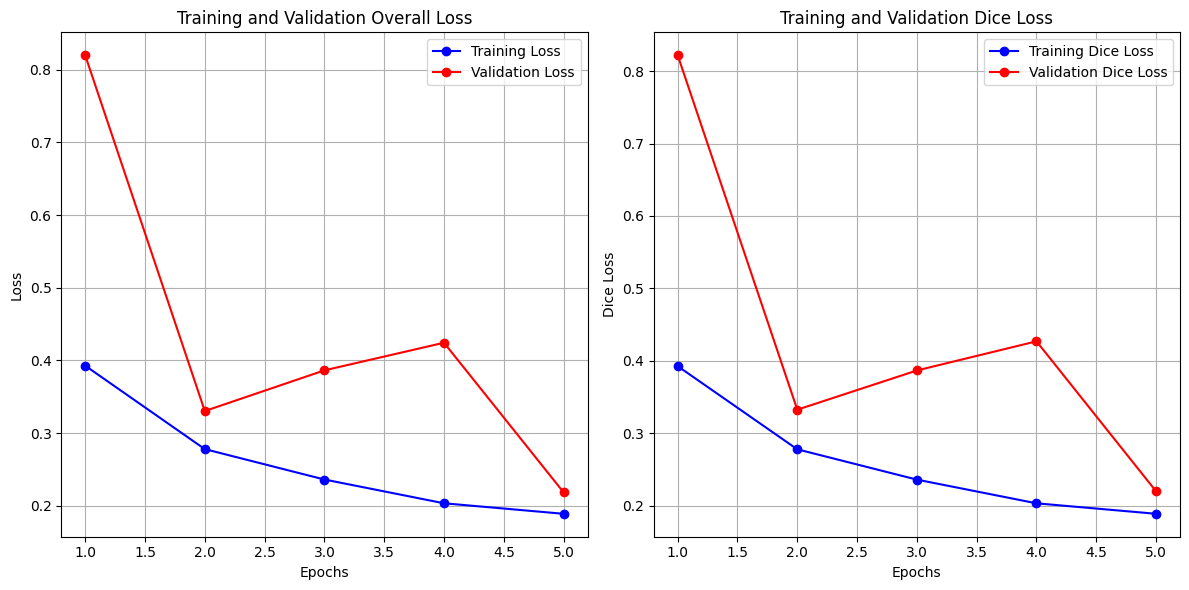

Last training overall loss: 0.18911132216453552
Last validation overall loss: 0.21863342821598053
Last training dice loss: 0.18911132216453552
Last validation dice loss: 0.22014601528644562


In [ ]:
import matplotlib.pyplot as plt

# Get the training history data
history_dict = history.history

# Extract losses
training_loss = history_dict['loss']
val_loss = history_dict['val_loss']
training_dice_loss = history_dict['dice_loss']
val_dice_loss = history_dict['val_dice_loss']

epochs = range(1, len(training_loss) + 1)

plt.figure(figsize=(12, 6))

# Plot overall loss
plt.subplot(1, 2, 1)
plt.plot(epochs, training_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Overall Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Dice Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, training_dice_loss, 'bo-', label='Training Dice Loss')
plt.plot(epochs, val_dice_loss, 'ro-', label='Validation Dice Loss')
plt.title('Training and Validation Dice Loss')
plt.xlabel('Epochs')
plt.ylabel('Dice Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Last training overall loss:", training_loss[-1])
print("Last validation overall loss:", val_loss[-1])
print("Last training dice loss:", training_dice_loss[-1])
print("Last validation dice loss:", val_dice_loss[-1])

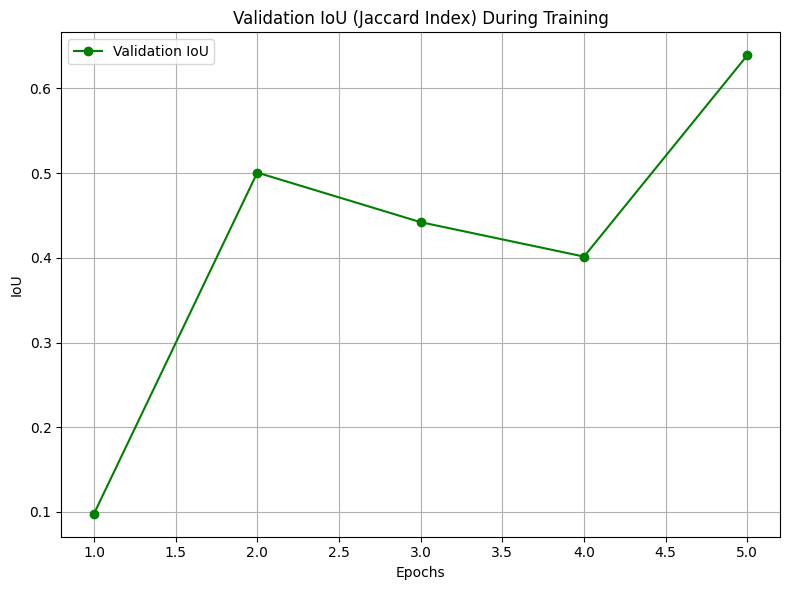

Last validation IoU: 0.6391480814125948


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get the training history data
history_dict = history.history

# Extract validation dice loss
val_dice_loss = history_dict['val_dice_loss']

# Calculate Validation Dice Coefficient (1 - Dice Loss)
val_dice_coefficient = np.array([1 - loss for loss in val_dice_loss])

# Calculate IoU from Dice Coefficient: IoU = Dice / (2 - Dice)
# Handle cases where 2 - Dice is zero or negative to avoid division by zero or invalid results
# This typically shouldn't happen with valid Dice coefficients (0 to 1)
val_iou = val_dice_coefficient / (2 - val_dice_coefficient)

epochs = range(1, len(val_iou) + 1)

plt.figure(figsize=(8, 6))

# Plot IoU
plt.plot(epochs, val_iou, 'go-', label='Validation IoU')
plt.title('Validation IoU (Jaccard Index) During Training')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Last validation IoU:", val_iou[-1])

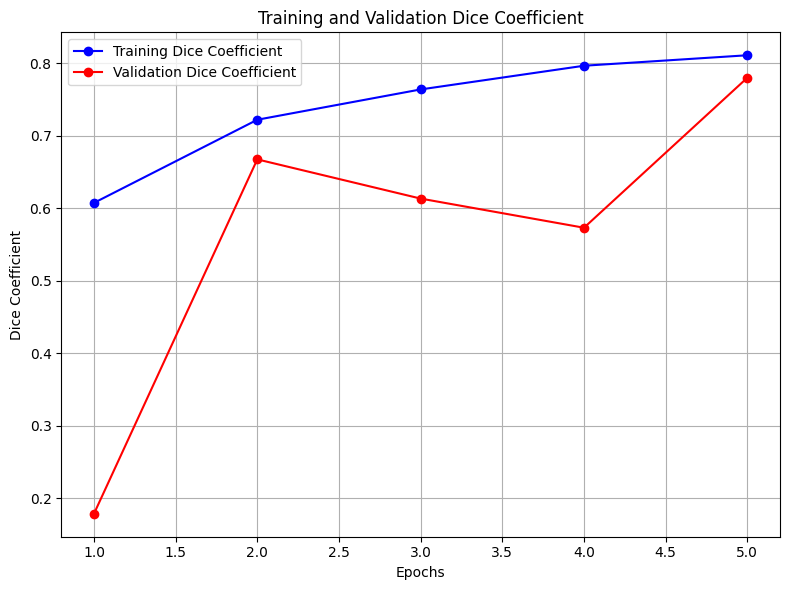

Last training Dice Coefficient: 0.8108886778354645
Last validation Dice Coefficient: 0.7798539847135544


In [ ]:
import matplotlib.pyplot as plt

# Get the training history data
history_dict = history.history

# Extract dice losses
training_dice_loss = history_dict['dice_loss']
val_dice_loss = history_dict['val_dice_loss']

# Calculate Dice Coefficient (1 - Dice Loss)
training_dice_coefficient = [1 - loss for loss in training_dice_loss]
val_dice_coefficient = [1 - loss for loss in val_dice_loss]

epochs = range(1, len(training_dice_coefficient) + 1)

plt.figure(figsize=(8, 6))

# Plot Dice Coefficient
plt.plot(epochs, training_dice_coefficient, 'bo-', label='Training Dice Coefficient')
plt.plot(epochs, val_dice_coefficient, 'ro-', label='Validation Dice Coefficient')
plt.title('Training and Validation Dice Coefficient')
plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Last training Dice Coefficient:", training_dice_coefficient[-1])
print("Last validation Dice Coefficient:", val_dice_coefficient[-1])

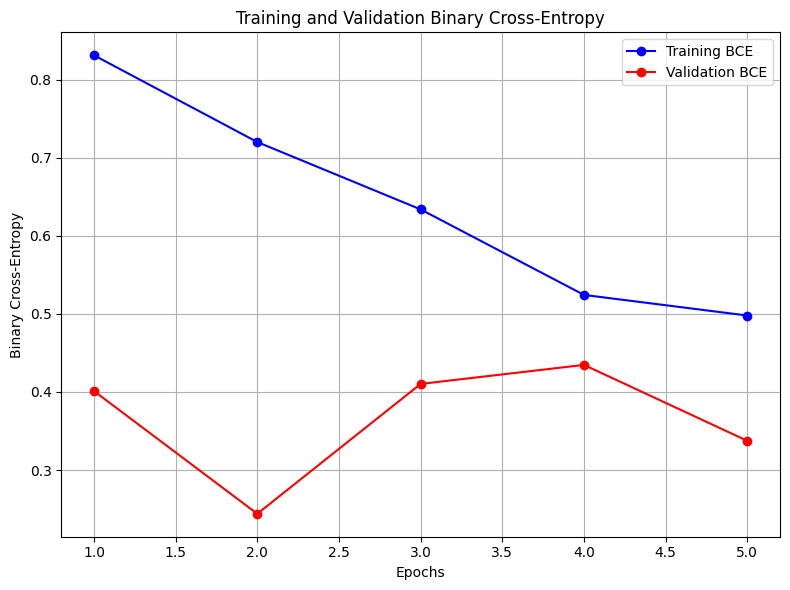

Last training Binary Cross-Entropy: 0.4979713559150696
Last validation Binary Cross-Entropy: 0.33741477131843567


In [ ]:
import matplotlib.pyplot as plt

# Get the training history data
history_dict = history.history

# Extract binary cross-entropy losses
training_bce = history_dict['binary_crossentropy']
val_bce = history_dict['val_binary_crossentropy']

epochs = range(1, len(training_bce) + 1)

plt.figure(figsize=(8, 6))

# Plot Binary Cross-Entropy
plt.plot(epochs, training_bce, 'bo-', label='Training BCE')
plt.plot(epochs, val_bce, 'ro-', label='Validation BCE')
plt.title('Training and Validation Binary Cross-Entropy')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross-Entropy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Last training Binary Cross-Entropy:", training_bce[-1])
print("Last validation Binary Cross-Entropy:", val_bce[-1])

In [ ]:
print("Available metrics in history_dict:")
for key in history.history.keys():
    print(f"- {key}")

Available metrics in history_dict:
- binary_crossentropy
- dice_loss
- loss
- val_binary_crossentropy
- val_dice_loss
- val_loss


In [ ]:
history_dict = history.history
epochs = range(1, len(history_dict['loss']) + 1)

print("--- Metrics per Epoch ---")
for epoch in epochs:
    print(f"\nEpoch {epoch}:")
    for key in history_dict.keys():
        # Check if the list for the current key has enough elements for the current epoch
        if epoch - 1 < len(history_dict[key]):
            print(f"  {key}: {history_dict[key][epoch - 1]:.4f}")
        else:
            print(f"  {key}: N/A") # In case some metrics are not available for all epochs

--- Metrics per Epoch ---

Epoch 1:
  binary_crossentropy: 0.8315
  dice_loss: 0.3928
  loss: 0.3928
  val_binary_crossentropy: 0.4013
  val_dice_loss: 0.8218
  val_loss: 0.8197

Epoch 2:
  binary_crossentropy: 0.7203
  dice_loss: 0.2781
  loss: 0.2781
  val_binary_crossentropy: 0.2439
  val_dice_loss: 0.3328
  val_loss: 0.3304

Epoch 3:
  binary_crossentropy: 0.6340
  dice_loss: 0.2363
  loss: 0.2363
  val_binary_crossentropy: 0.4103
  val_dice_loss: 0.3869
  val_loss: 0.3864

Epoch 4:
  binary_crossentropy: 0.5244
  dice_loss: 0.2036
  loss: 0.2036
  val_binary_crossentropy: 0.4347
  val_dice_loss: 0.4271
  val_loss: 0.4244

Epoch 5:
  binary_crossentropy: 0.4980
  dice_loss: 0.1891
  loss: 0.1891
  val_binary_crossentropy: 0.3374
  val_dice_loss: 0.2201
  val_loss: 0.2186


In [ ]:
history_dict = history.history
epochs = range(1, len(history_dict['loss']) + 1)

# Calculate Dice Coefficients from Dice Losses
training_dice_loss = history_dict['dice_loss']
val_dice_loss = history_dict['val_dice_loss']

training_dice_coefficient = [1 - loss for loss in training_dice_loss]
val_dice_coefficient = [1 - loss for loss in val_dice_loss]

# Calculate IoU from Dice Coefficients: IoU = Dice / (2 - Dice)
training_iou = [dc / (2 - dc) if (2 - dc) != 0 else 0 for dc in training_dice_coefficient]
val_iou = [dc / (2 - dc) if (2 - dc) != 0 else 0 for dc in val_dice_coefficient]

print("--- Metrics per Epoch ---")
for epoch in epochs:
    print(f"\nEpoch {epoch}:")
    # Existing metrics
    for key in history_dict.keys():
        if epoch - 1 < len(history_dict[key]):
            print(f"  {key}: {history_dict[key][epoch - 1]:.4f}")
        else:
            print(f"  {key}: N/A")
    # New Dice and IoU metrics
    if epoch - 1 < len(training_dice_coefficient):
        print(f"  training_dice_coefficient: {training_dice_coefficient[epoch - 1]:.4f}")
    if epoch - 1 < len(val_dice_coefficient):
        print(f"  val_dice_coefficient: {val_dice_coefficient[epoch - 1]:.4f}")
    if epoch - 1 < len(training_iou):
        print(f"  training_iou: {training_iou[epoch - 1]:.4f}")
    if epoch - 1 < len(val_iou):
        print(f"  val_iou: {val_iou[epoch - 1]:.4f}")

--- Metrics per Epoch ---

Epoch 1:
  binary_crossentropy: 0.8315
  dice_loss: 0.3928
  loss: 0.3928
  val_binary_crossentropy: 0.4013
  val_dice_loss: 0.8218
  val_loss: 0.8197
  training_dice_coefficient: 0.6072
  val_dice_coefficient: 0.1782
  training_iou: 0.4360
  val_iou: 0.0978

Epoch 2:
  binary_crossentropy: 0.7203
  dice_loss: 0.2781
  loss: 0.2781
  val_binary_crossentropy: 0.2439
  val_dice_loss: 0.3328
  val_loss: 0.3304
  training_dice_coefficient: 0.7219
  val_dice_coefficient: 0.6672
  training_iou: 0.5649
  val_iou: 0.5006

Epoch 3:
  binary_crossentropy: 0.6340
  dice_loss: 0.2363
  loss: 0.2363
  val_binary_crossentropy: 0.4103
  val_dice_loss: 0.3869
  val_loss: 0.3864
  training_dice_coefficient: 0.7637
  val_dice_coefficient: 0.6131
  training_iou: 0.6178
  val_iou: 0.4421

Epoch 4:
  binary_crossentropy: 0.5244
  dice_loss: 0.2036
  loss: 0.2036
  val_binary_crossentropy: 0.4347
  val_dice_loss: 0.4271
  val_loss: 0.4244
  training_dice_coefficient: 0.7964
  val_

In [ ]:
import tensorflow as tf

# Ensure the custom dice_loss function is defined, as it's needed for loading the model
# (Assuming dice_loss is already defined from previous steps)
# If not, it would need to be re-defined here:
# from tensorflow.keras import backend as K
# def dice_loss(y_true, y_pred):
#     smooth = 1e-7
#     y_true_f = K.flatten(y_true)
#     y_pred_f = K.flatten(y_pred)
#     intersection = K.sum(y_true_f * y_pred_f)
#     sum_areas = K.sum(y_true_f) + K.sum(y_pred_f)
#     return 1 - (2. * intersection + smooth) / (sum_areas + smooth)

# Load the saved model
loaded_model = tf.keras.models.load_model('unet_mango_segmentation.h5', custom_objects={'dice_loss': dice_loss})

print("Model 'unet_mango_segmentation.h5' loaded successfully.")
# Optionally, print a summary of the loaded model to confirm
# loaded_model.summary()

Model 'unet_mango_segmentation.h5' loaded successfully.
